# Financial Loss Mitigation Study
## Arman Azhand

The purpose of this Jupyter notebook is for workflow - and should not be reflected as the final report.  
Please view the PDF for the in-depth and well-formatted report on the methodology and results of this study.

## Data Loading and Processing

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
data = pd.read_csv("/content/drive/MyDrive/data/final_project(5).csv")

In [2]:
data.describe()

,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,...,x41,x42,x43,x44,x45,x46,x47,x48,x49,y
count,159974.000000,159975.000000,159962.000000,159963.000000,159974.000000,159963.000000,159974.000000,159973.000000,159979.000000,159970.000000,...,159960.000000,159974.000000,159963.000000,159960.000000,159971.000000,159969.000000,159963.000000,159968.000000,159968.000000,160000.000000
mean,-0.001028,0.001358,-1.150145,-0.024637,-0.000549,0.013582,-1.670670,-7.692795,-0.030540,0.005462,...,6.701076,-1.833820,-0.002091,-0.006250,0.000885,-12.755395,0.028622,-0.000224,-0.674224,0.401231
std,0.371137,6.340632,13.273480,8.065032,6.382293,7.670076,19.298665,30.542264,8.901185,6.355040,...,18.680196,5.110705,1.534952,4.164595,0.396621,36.608641,4.788157,1.935501,15.036738,0.490149
min,-1.592635,-26.278302,-59.394048,-35.476594,-28.467536,-33.822988,-86.354483,-181.506976,-37.691045,-27.980659,...,-82.167224,-27.933750,-6.876234,-17.983487,-1.753221,-201.826828,-21.086333,-8.490155,-65.791191,0.000000
25%,-0.251641,-4.260973,-10.166536,-5.454438,-4.313118,-5.148130,-14.780146,-27.324771,-6.031058,-4.260619,...,-5.804080,-5.162869,-1.039677,-2.812055,-0.266518,-36.428329,-3.216016,-1.320800,-10.931753,0.000000
50%,-0.002047,0.004813,-1.340932,-0.031408,0.000857,0.014118,-1.948594,-6.956789,-0.016840,0.006045,...,6.840110,-1.923754,-0.004385,-0.010484,0.001645,-12.982497,0.035865,-0.011993,-0.574410,0.000000
75%,0.248532,4.284220,7.871676,5.445179,4.306660,5.190749,11.446931,12.217071,5.972349,4.305734,...,19.266367,1.453507,1.033275,2.783274,0.269049,11.445443,3.268028,1.317703,9.651072,1.000000
max,1.600849,27.988178,63.545653,38.906025,26.247812,35.550110,92.390605,149.150634,39.049831,27.377842,...,100.050432,22.668041,6.680922,19.069759,1.669205,150.859415,20.836854,8.226552,66.877604,1.000000


In [3]:
data["x37"] = data["x37"].str.replace(r"[$,]", "", regex=True).astype(float)
data["x32"] = data["x32"].str.replace("%", "", regex=False).astype(float)

In [4]:
data.isna().sum()

,0
x0,26
x1,25
x2,38
x3,37
x4,26
x5,37
x6,26
x7,27
x8,21
x9,30


In [5]:
data_mode = data.mode().iloc[0]
data = data.fillna(data_mode)

In [6]:
data.isna().sum()

,0
x0,0
x1,0
x2,0
x3,0
x4,0
x5,0
x6,0
x7,0
x8,0
x9,0


In [7]:
scaler = StandardScaler()
numeric_cols = data.select_dtypes(include=['number']).columns[:-1]
data[numeric_cols] = scaler.fit_transform(data[numeric_cols])
data = pd.get_dummies(data, columns=["x24", "x29", "x30"], drop_first=True)

In [8]:
cost_fNeg = 31.56
cost_fPos = 102.33
threshold = (cost_fNeg)/(cost_fNeg + cost_fPos)
weights = {0: 102.33, 1: 31.56}

In [9]:
X_train, X_test, y_train, y_test = train_test_split(data.drop("y", axis=1), data["y"], test_size=0.2, random_state=611)
X = data.drop("y", axis=1)
y = data["y"]

## Loss Function

A false negative costs \\$31.56  
A false positive costs \\$102.33

In [10]:
from sklearn.metrics import make_scorer, confusion_matrix

def dollar_loss_func(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = (fp * 102.33) + (fn * 31.56)
    return total_cost

dollar_scorer = make_scorer(dollar_loss_func, greater_is_better=False, response_method='predict')

## GridSearch for the best performing parameters

### XGBoost
### Logistic Regression
### Random Forest

In [11]:
import cuml
from cuml.linear_model import LogisticRegression as cuLogReg
from cuml.ensemble import RandomForestClassifier as cuRF
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

sample_weights = np.where(y_train == 0, 102.33, 31.56)

models = {
    'XGBoost': {
        'model': xgb.XGBClassifier(device='cuda', tree_method='hist', random_state=611),
        'params': {
            'n_estimators': [500],
            'learning_rate': [0.05, 0.1],
            'max_depth': [4, 6, 8],
            'colsample_bylevel': [0.5, 0.7, 0.9]
        }
    },
    'LogisticRegression': {
        'model': cuLogReg(max_iter=2000),
        'params': {
            'C': [0.1, 1.0, 10.0],
            'penalty': ['l2']
        }
    },
    'RandomForest': {
        'model': cuRF(random_state=42),
        'params': {
            'n_estimators': [300],
            'max_depth': [10, 15, 20],
            'max_features': [0.5, 'sqrt'],
            "min_samples_split": [10,6,2]
        }
    }
}

Tuning XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [01:23:54] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


--- XGBoost Results ---
Best Params: {'colsample_bylevel': 0.9, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 500}
Test Set Loss: $115,336.71
Test Set Accuracy: 94.3187%

Tuning LogisticRegression...
--- LogisticRegression Results ---
Best Params: {'C': 0.1, 'penalty': 'l2'}
Test Set Loss: $533,060.70
Test Set Accuracy: 70.3563%

Tuning RandomForest...
--- RandomForest Results ---
Best Params: {'max_depth': 20, 'max_features': 0.5, 'min_samples_split': 6, 'n_estimators': 300}
Test Set Loss: $128,433.15
Test Set Accuracy: 93.0500%



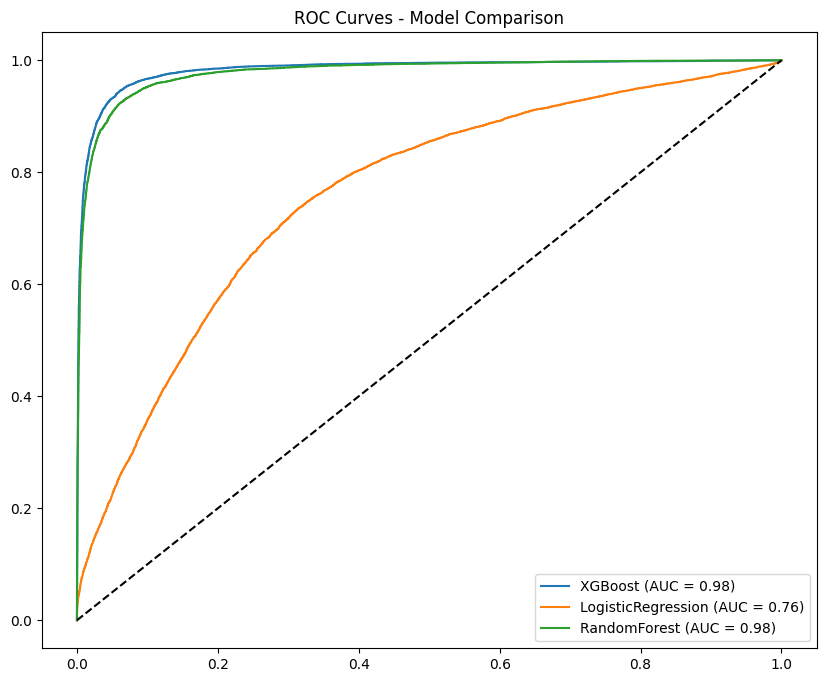

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc, accuracy_score

best_models = {}
cv_results_list = []
results = []
plt.figure(figsize=(10, 8))

for name, config in models.items():
    print(f"Tuning {name}...")
    gs = GridSearchCV(config['model'], config['params'], scoring=dollar_scorer, cv=5, n_jobs=1)
    gs.fit(X_train, y_train)

    res_df = pd.DataFrame(gs.cv_results_)
    res_df['Model_Name'] = name
    cv_results_list.append(res_df)

    best_model = gs.best_estimator_
    best_models[name] = best_model
    y_pred = best_model.predict(X_test)

    raw_probas = best_model.predict_proba(X_test)

    # Ensure raw_probas is a NumPy array for consistent indexing
    if isinstance(raw_probas, pd.DataFrame):
        raw_probas = raw_probas.values
    elif isinstance(raw_probas, pd.Series):
        raw_probas = raw_probas.values

    # Extract positive class probabilities
    if raw_probas.ndim == 2 and raw_probas.shape[1] == 2:
        y_prob = raw_probas[:, 1]
    elif raw_probas.ndim == 1:
        # If it's 1D, assume it's already the positive class probability
        y_prob = raw_probas
    elif raw_probas.ndim == 2 and raw_probas.shape[1] == 1:
        # If it's 2D with 1 column (e.g., from some specific models), flatten it
        y_prob = raw_probas.flatten()
    else:
        raise ValueError(f"Unexpected shape {raw_probas.shape} from predict_proba output for model {name}.")

    loss = dollar_loss_func(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    avg_loss_per_sample = loss / len(y_test)
    projected_total_loss = avg_loss_per_sample * 160000

    print(f"--- {name} Results ---")
    print(f"Best Params: {gs.best_params_}")
    print(f"Test Set Loss: ${loss:,.2f}")
    print(f"Test Set Accuracy: {acc:.4%}\n")

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

    # results.append({
    #    'Model': name,
    #    'Best Params': gs.best_params_,
    #    'Test Set Loss': f"${loss:,.2f}",
    #    'Projected 160k Loss': f"${projected_total_loss:,.2f}"
    # })

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves - Model Comparison')
plt.legend()
plt.show()

# Export hyperparameter tuning logs to CSV
pd.concat(cv_results_list).to_csv('hyperparameter_tuning_results.csv', index=False)

## Results

Classification report and confusion matrix for our "best" performing model

In [14]:

from sklearn.model_selection import cross_val_predict

best_xgb = gs.best_estimator_

print("Generating out-of-sample predictions for all 160,000 rows...")
y_pred_all = cross_val_predict(best_xgb, X, y, cv=5, n_jobs=1)

tn, fp, fn, tp = confusion_matrix(y, y_pred_all).ravel()
total_actual_loss = (fp * 102.33) + (fn * 31.56)

print(f"Total Financial Impact: ${total_actual_loss:,.2f}")
print(f"False Positives: {fp} (Cost: ${fp * 102.33:,.2f})")
print(f"False Negatives: {fn} (Cost: ${fn * 31.56:,.2f})")

Generating out-of-sample predictions for all 160,000 rows...
Total Financial Impact: $634,186.83
False Positives: 4091 (Cost: $418,632.03)
False Negatives: 6830 (Cost: $215,554.80)


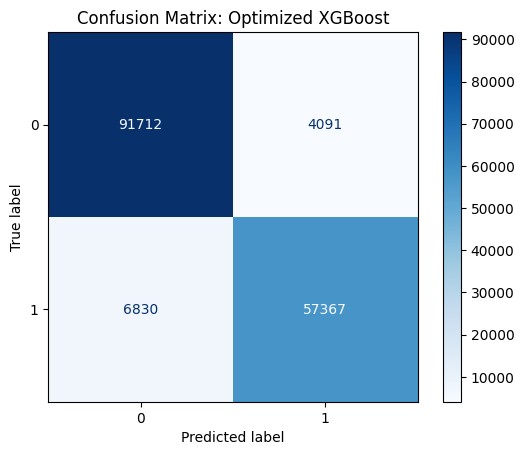

In [15]:
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y, y_pred_all)).plot(cmap='Blues')
plt.title('Confusion Matrix: Optimized XGBoost')
plt.show()

In [16]:
from sklearn.metrics import classification_report

print("Classification Report for Optimized XGBoost (Full Dataset Predictions):")
print(classification_report(y, y_pred_all))

Classification Report for Optimized XGBoost (Full Dataset Predictions):
              precision    recall  f1-score   support

           0       0.93      0.96      0.94     95803
           1       0.93      0.89      0.91     64197

    accuracy                           0.93    160000
   macro avg       0.93      0.93      0.93    160000
weighted avg       0.93      0.93      0.93    160000



/tmp/ipykernel_1828/2409546899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


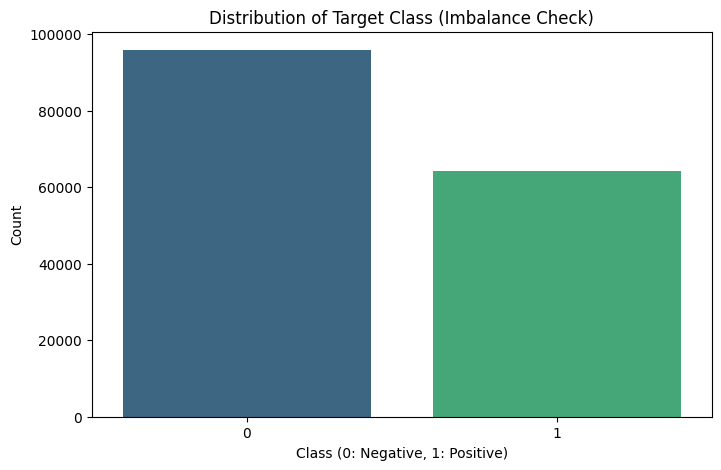

In [21]:
def plot_imbalance(y):
    plt.figure(figsize=(8, 5))
    sns.countplot(x=y, palette='viridis')
    plt.title('Distribution of Target Class (Imbalance Check)')
    plt.xlabel('Class (0: Negative, 1: Positive)')
    plt.ylabel('Count')
    plt.show()

plot_imbalance(y)